<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

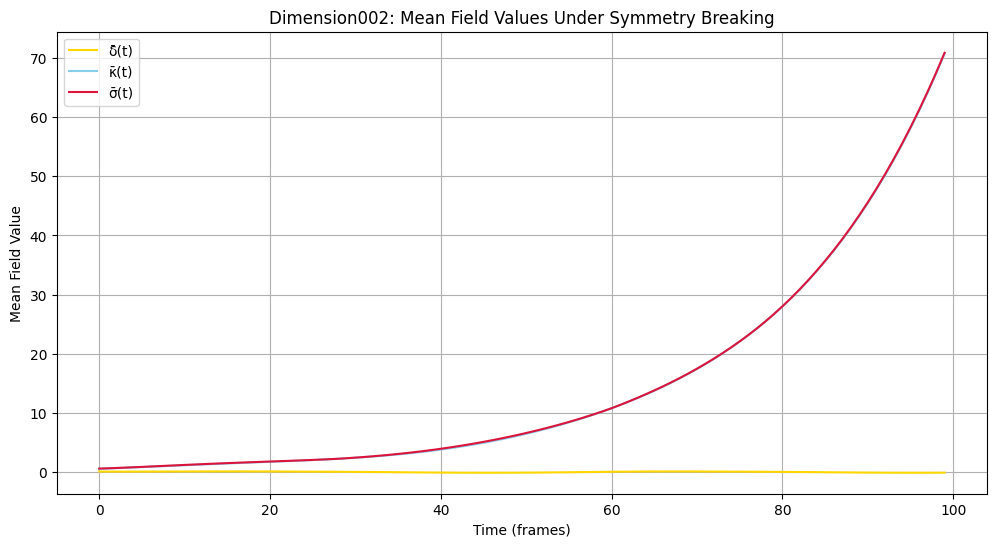

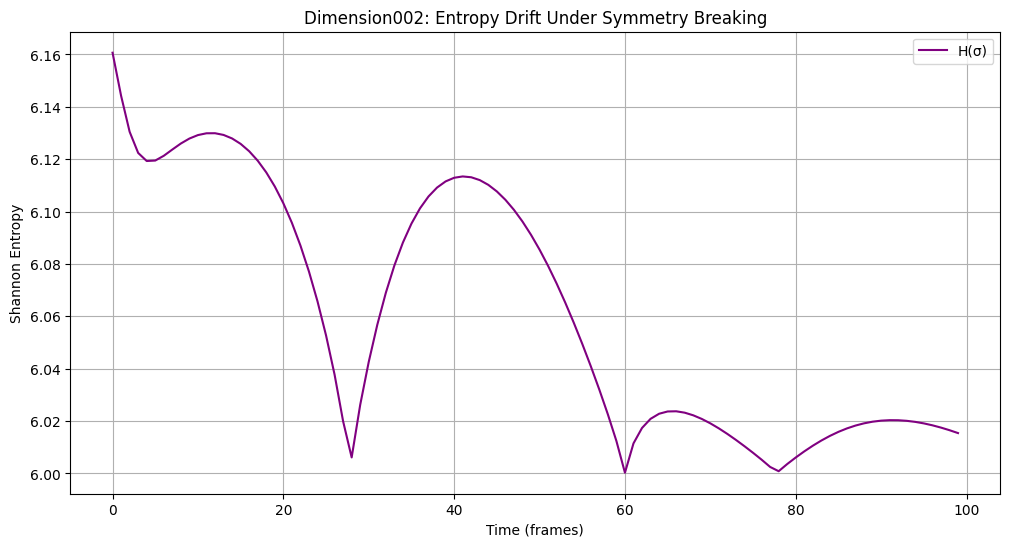

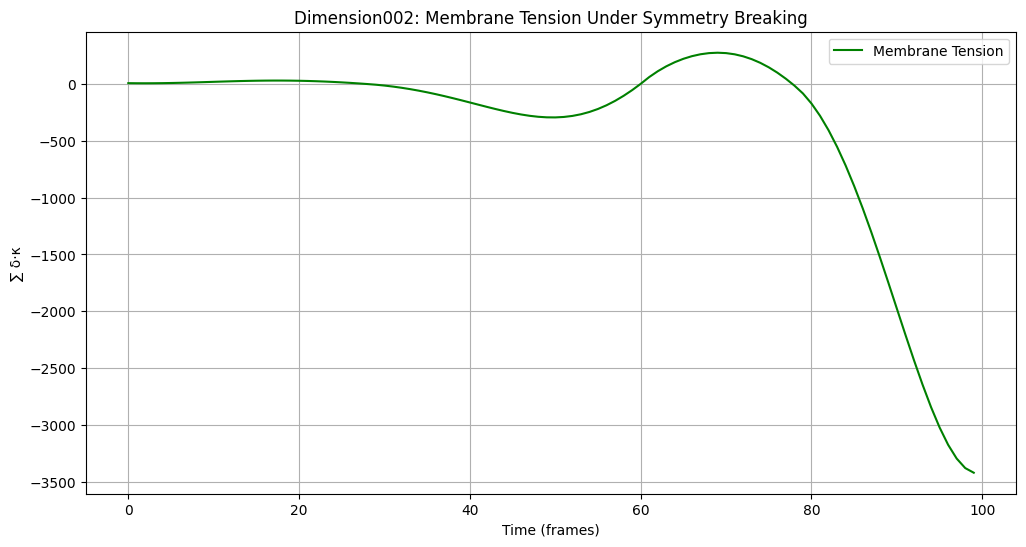

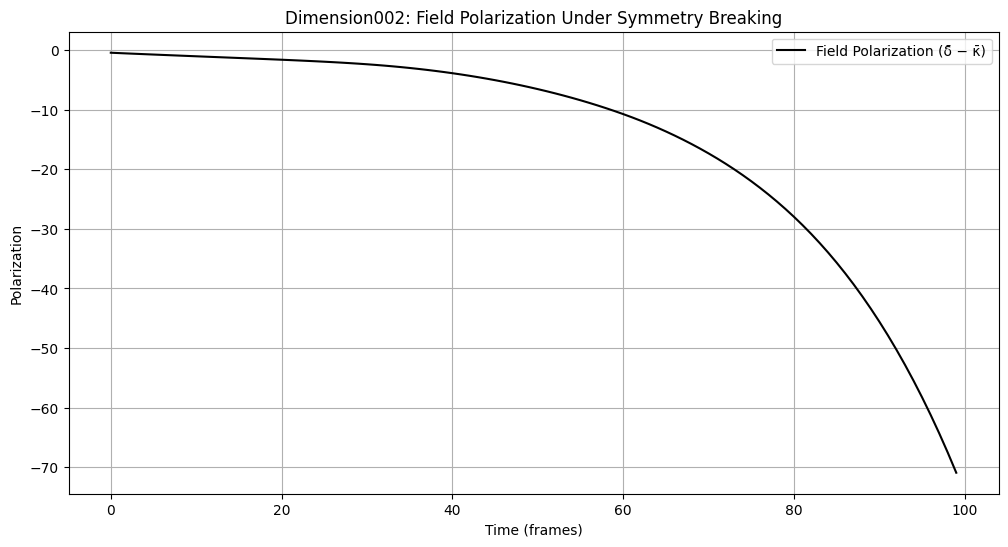

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------
# Build Network with Skewed Edges
# -------------------------------
def build_skewed_network(boundary_size=8, bulk_size=64):
    G = nx.Graph()
    boundary = [f"B{i}" for i in range(boundary_size)]
    bulk = [f"U{i}" for i in range(bulk_size)]
    G.add_nodes_from(boundary, region='boundary')
    G.add_nodes_from(bulk, region='bulk')

    for i, b in enumerate(boundary):
        skew = 6 if i < boundary_size // 2 else 2
        for u in np.random.choice(bulk, size=skew, replace=False):
            G.add_edge(b, u)

    for i in range(bulk_size):
        for j in range(i + 1, bulk_size):
            if np.random.rand() < 0.1:
                G.add_edge(f"U{i}", f"U{j}")
    return G

# -------------------------------
# Initialization
# -------------------------------
def initialize_fields(G, delta_init=0.5, kappa_init=0.5):
    for node in G.nodes:
        region = G.nodes[node]['region']
        G.nodes[node]['delta'] = delta_init if region == 'boundary' else 0.0
        G.nodes[node]['kappa'] = kappa_init if region == 'bulk' else 0.0

# -------------------------------
# Curvature, Tension, Entropy
# -------------------------------
def compute_curvature(G):
    return {n: abs(G.nodes[n]['delta'] - G.nodes[n]['kappa']) for n in G.nodes}

def compute_membrane_tension(G):
    tension = 0.0
    for u, v in G.edges:
        d = G.nodes[u]['delta'] * G.nodes[v]['kappa']
        d += G.nodes[v]['delta'] * G.nodes[u]['kappa']
        tension += d
    return tension

def compute_entropy(values):
    values = np.array(values)
    total = np.sum(values)
    if total == 0:
        return 0.0
    probs = values / total
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

# -------------------------------
# Recursive Update with Asymmetry
# -------------------------------
def update_fields(G, t, delta_base=1.0, kappa_base=0.7, alpha=0.85, beta=0.95, gamma=0.1):
    delta_t = delta_base * np.sin(2 * np.pi * t / 50)
    kappa_t = kappa_base * np.cos(2 * np.pi * t / 50)
    curvature = compute_curvature(G)

    for node in G.nodes:
        region = G.nodes[node]['region']
        prev_delta = G.nodes[node]['delta']
        prev_kappa = G.nodes[node]['kappa']
        sigma = curvature[node]

        if region == 'boundary':
            G.nodes[node]['delta'] = alpha * prev_delta + (1 - alpha) * delta_t - gamma * sigma
            G.nodes[node]['kappa'] = 0.0
        else:
            G.nodes[node]['kappa'] = beta * prev_kappa + (1 - beta) * kappa_t + gamma * sigma
            G.nodes[node]['delta'] = 0.0

# -------------------------------
# Run Simulation
# -------------------------------
def run_symmetry_breaking(frames=100):
    G = build_skewed_network()
    initialize_fields(G)

    delta_means, kappa_means, sigma_means = [], [], []
    entropy_vals, tension_vals, polarization_vals = [], [], []

    for t in range(frames):
        update_fields(G, t)
        delta_vals = [G.nodes[n]['delta'] for n in G.nodes]
        kappa_vals = [G.nodes[n]['kappa'] for n in G.nodes]
        sigma_vals = list(compute_curvature(G).values())

        delta_mean = np.mean(delta_vals)
        kappa_mean = np.mean(kappa_vals)
        delta_means.append(delta_mean)
        kappa_means.append(kappa_mean)
        sigma_means.append(np.mean(sigma_vals))
        entropy_vals.append(compute_entropy(sigma_vals))
        tension_vals.append(compute_membrane_tension(G))
        polarization_vals.append(delta_mean - kappa_mean)

    return delta_means, kappa_means, sigma_means, entropy_vals, tension_vals, polarization_vals

# -------------------------------
# Run and Plot
# -------------------------------
results = run_symmetry_breaking()
frames = range(100)

plt.figure(figsize=(12, 6))
plt.plot(frames, results[0], label='δ̄(t)', color='gold')
plt.plot(frames, results[1], label='κ̄(t)', color='skyblue')
plt.plot(frames, results[2], label='σ̄(t)', color='crimson')
plt.title("Dimension002: Mean Field Values Under Symmetry Breaking")
plt.xlabel("Time (frames)")
plt.ylabel("Mean Field Value")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(frames, results[3], label='H(σ)', color='purple')
plt.title("Dimension002: Entropy Drift Under Symmetry Breaking")
plt.xlabel("Time (frames)")
plt.ylabel("Shannon Entropy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(frames, results[4], label='Membrane Tension', color='green')
plt.title("Dimension002: Membrane Tension Under Symmetry Breaking")
plt.xlabel("Time (frames)")
plt.ylabel("∑ δ·κ")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(frames, results[5], label='Field Polarization (δ̄ − κ̄)', color='black')
plt.title("Dimension002: Field Polarization Under Symmetry Breaking")
plt.xlabel("Time (frames)")
plt.ylabel("Polarization")
plt.legend()
plt.grid(True)
plt.show()
